In [1]:
import torch
from src.SD3_custom_pipeline import StableDiffusion3Pipeline
from src.FLUX_custom_pipeline import FluxPipeline 
from src.PixartAlpha_custom_pipeline import PixArtAlphaPipeline

In [4]:
import pandas as pd

def print_sorted_layers(csv_path: str):
    # Read CSV
    df = pd.read_csv(csv_path)
    
    # Separate cfg and layers
    cfg_row = df[df['Mode'] == 'cfg']
    layer_rows = df[df['Mode'].str.startswith('layer_')]
    
    # Sort layers by numeric suffix
    layer_rows = layer_rows.assign(
        layer_num=layer_rows['Mode'].str.extract(r'(\d+)').astype(int)
    ).sort_values('layer_num')
    
    # Combine cfg first, then layers
    sorted_df = pd.concat([cfg_row, layer_rows.drop(columns='layer_num')], ignore_index=True)
    
    # Print each row
    for _, row in sorted_df.iterrows():
        print(f"{row['Average_Score']:.6f}")


In [17]:
print_sorted_layers('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/pixart_aesthetic_quality_ablations.csv')

6.767309
4.707232
4.311221
2.906108
6.487499
6.672342
6.770477
6.552483
6.735517
6.713384
6.792584
6.707991
6.730054
6.675929
6.703624
6.727149
6.709313
6.723296
6.712945
6.544342
6.745673
6.773856
6.658547
6.647934
6.568256
6.750749
6.923934
3.756602
2.869629


In [2]:
def sort_and_print_layers(data_str: str):
    # Split lines and parse into (name, value)
    lines = [line.strip() for line in data_str.strip().splitlines() if line.strip()]
    entries = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            name, value = parts
            entries.append((name, float(value)))

    # Separate cfg and layers
    cfg_entry = [e for e in entries if e[0] == "cfg"]
    layer_entries = [e for e in entries if e[0].startswith("layer_")]

    # Sort layers by numeric index
    layer_entries.sort(key=lambda x: int(x[0].split("_")[1]))

    # Combine cfg first, then layers
    ordered = cfg_entry + layer_entries

    # Print out formatted results
    for name, value in ordered:
        print(f"{value:.6f}")


In [3]:
sort_and_print_layers("""layer_7     0.489353
layer_0     0.503016
layer_15    0.507296
layer_12    0.503992
layer_9     0.517245
layer_13    0.489617
layer_8     0.489069
layer_14    0.503761
layer_1     0.499028
layer_6     0.486807
layer_17    0.515697
layer_10    0.486172
layer_5     0.490968
layer_2     0.378460
cfg         0.482867
layer_3     0.521592
layer_18    0.536665
layer_4     0.515241
layer_11    0.528635
layer_16    0.500193""")

0.482867
0.503016
0.499028
0.378460
0.521592
0.515241
0.490968
0.486807
0.489353
0.489069
0.517245
0.486172
0.528635
0.503992
0.489617
0.503761
0.507296
0.500193
0.515697
0.536665


In [2]:
data = """cfg 0.19000
msg_scale_1.25 0.21000
msg_scale_1.5 0.20000
msg_scale_1.75 0.24000
msg_scale_2.0 0.23000
msg_scale_2.25 0.21000
msg_scale_2.5 0.21000
msg_scale_2.75 0.23000
msg_scale_3.0 0.26000
msg_scale_3.25 0.27000
msg_scale_3.5 0.27000"""

lines = [line.split() for line in data.splitlines()]
cfg = [x for x in lines if x[0] == "cfg"]
scales = sorted(
    [x for x in lines if x[0].startswith("msg_scale_")],
    key=lambda x: float(x[0].split("_")[2])
)
for _, score in cfg + scales:
    print(score)

0.19000
0.21000
0.20000
0.24000
0.23000
0.21000
0.21000
0.23000
0.26000
0.27000
0.27000


In [2]:
def extract_ordered_values(s: str) -> list[float]:
    order = ["cfg", "stg", "msg_naive", "msg_fixed", "msg_weighted"]
    values = {}
    for line in s.strip().splitlines():
        parts = line.split()
        if len(parts) == 2:
            key, val = parts
            values[key] = float(val)
    for key in order:
        if key in values:
            print(values[key])


In [6]:
extract_ordered_values("""cfg 0.10000
msg_fixed 0.11000
msg_naive 0.03000
msg_weighted 0.07000
stg 0.09000
""")

0.1
0.09
0.03
0.11
0.07


In [3]:
def print_sorted_values(data_string):
    parsed_data = {}
    for line in data_string.strip().split('\n'):
        if line: # Ensure the line is not empty
            try:
                # Split on the first space to get key and value
                key, value = line.split(maxsplit=1) 
                parsed_data[key] = value
            except ValueError:
                # Skip any malformed lines
                print(f"Skipping malformed line: {line}")
                
    def get_sort_key(key_name):
        if key_name == 'cfg':
            return -1
        if key_name.startswith('layer_'):
            try:
                return int(key_name.split('_')[1])
            except (ValueError, IndexError):
                return float('inf') # Put at the end
        return float('inf')
    try:
        sorted_keys = sorted(parsed_data.keys(), key=get_sort_key)
    except Exception as e:
        print(f"An error occurred during sorting: {e}")
        return
    for key in sorted_keys:
        print(parsed_data[key])

In [7]:
print_sorted_values('''cfg 0.68000
layer_0 0.50000
layer_1 0.46000
layer_10 0.70000
layer_11 0.70000
layer_12 0.58000
layer_13 0.70000
layer_14 0.66000
layer_15 0.66000
layer_16 0.74000
layer_17 0.72000
layer_18 0.68000
layer_2 0.52000
layer_3 0.56000
layer_4 0.70000
layer_5 0.66000
layer_6 0.76000
layer_7 0.70000
layer_8 0.68000
layer_9 0.68000
''')

0.68000
0.50000
0.46000
0.52000
0.56000
0.70000
0.66000
0.76000
0.70000
0.68000
0.68000
0.70000
0.70000
0.58000
0.70000
0.66000
0.66000
0.74000
0.72000
0.68000


In [15]:
def extract_sorted_values(data_string: str) -> str:
    """
    Parses a string of layer data, sorts it by the numerical layer ID,
    and returns a string containing only the sorted values, one per line.
    
    The 'cfg' line is always placed first.
    """
    
    parsed_data = []
    
    # 1. Split the string into lines and process each one
    for line in data_string.strip().splitlines():
        if not line.strip():
            continue  # Skip empty lines
            
        try:
            # 2. Split line into label (e.g., '5_layers') and value (e.g., '6.294523')
            parts = line.split()
            if len(parts) != 2:
                continue # Skip lines that don't have exactly two parts
                
            label, value = parts
            
            # --- MODIFIED SECTION START ---
            
            # 3. Handle 'cfg' as a special case, giving it a sort key of -1
            if label == 'cfg':
                layer_id = -1
            else:
                # 4. Extract the number from other labels (e.g., '5_layers' -> 5)
                layer_id = int(label.split('_')[0])
            
            # 5. Store the data as a tuple (ID, value)
            parsed_data.append((layer_id, value))
            
            # --- MODIFIED SECTION END ---
            
        except (ValueError, IndexError):
            # Handle lines that don't match the expected format
            # (e.g., if 'layers' is missing or the ID isn't a number)
            continue
            
    # 6. Sort the list of tuples. Python automatically sorts by the first
    #    element: -1 (cfg), 1, 2, 3, 4...
    sorted_data = sorted(parsed_data)
    
    # 7. Extract only the values (the second element of each tuple)
    output_values = [value for layer_id, value in sorted_data]
    
    # 8. Join the values with newlines and return
    return "\n".join(output_values)

# --- Example Usage ---

# Your input data as a multi-line string
data = """
1_layers    6.300883
3_layers    6.300883
4_layers    6.300883
cfg         6.205116
2_layers    6.300883
"""

# Call the function
result = extract_sorted_values(data)

# Print the result
print(result)

6.205116
6.300883
6.300883
6.300883
6.300883


In [5]:
[6.349146 + 6.258917,
6.314505 + 6.256860,
6.343054 + 6.193571,

6.306289 + 6.191324,

6.343268 + 6.169125]





[12.608063000000001, 12.571365, 12.536625, 12.497613, 12.512393]

In [2]:
6.270427 / 6.257051 - 1

0.0021377482779028067

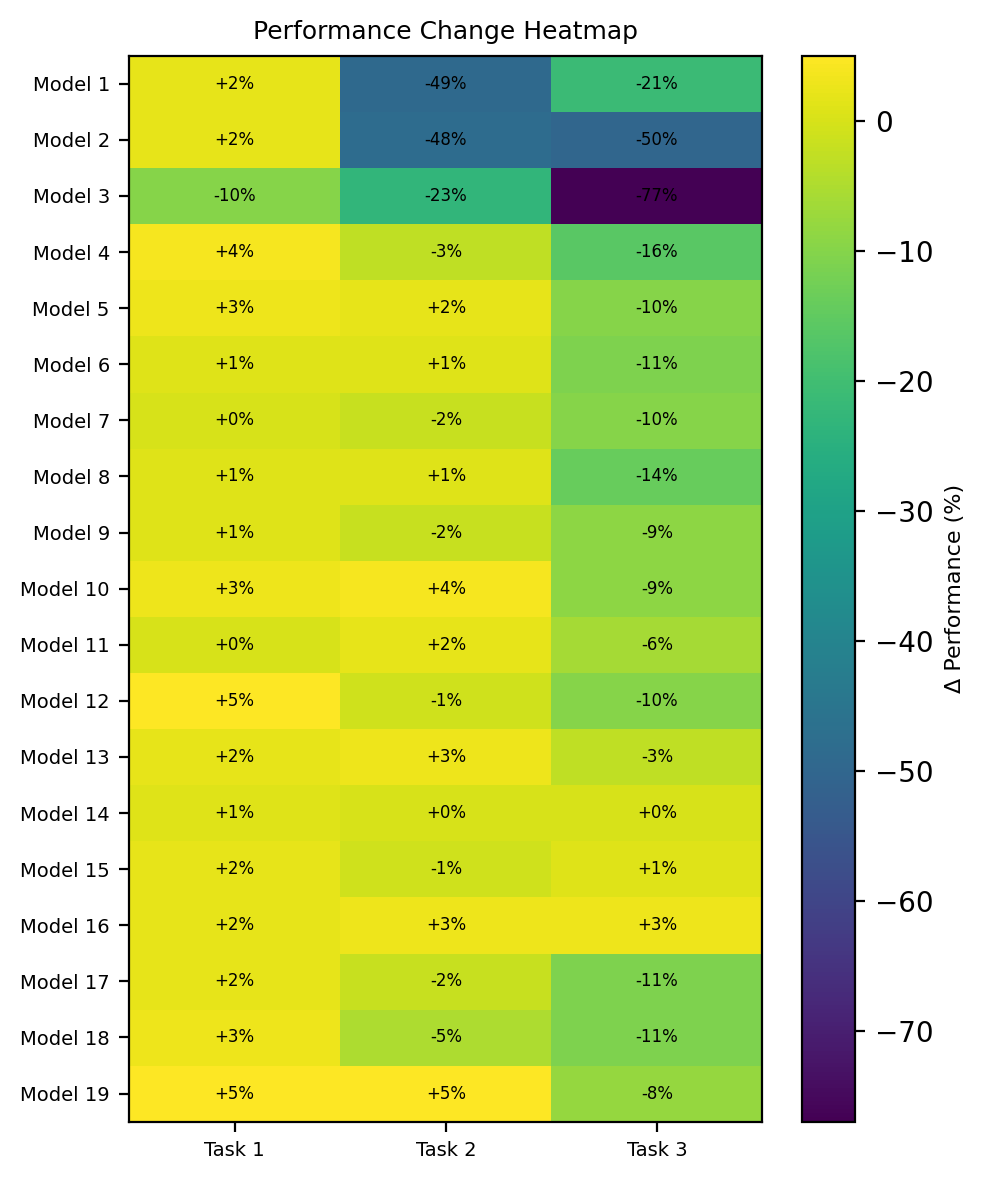

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# === Replace these three strings with your real data ===
task1_str = """
2%
2%
-10%
4%
3%
1%
0%
1%
1%
3%
0%
5%
2%
1%
2%
2%
2%
3%
5%
"""

task2_str = """
-49%
-48%
-23%
-3%
2%
1%
-2%
1%
-2%
4%
2%
-1%
3%
0%
-1%
3%
-2%
-5%
5%
"""

task3_str = """
-21%
-50%
-77%
-16%
-10%
-11%
-10%
-14%
-9%
-9%
-6%
-10%
-3%
0%
1%
3%
-11%
-11%
-8%
"""

# --- Helper to convert "4%" → 4.0 ---
def parse_percent_list(s):
    return np.array([float(x.replace("%","")) for x in s.split() if "%" in x])

# Convert three tasks → numeric vectors
vec1 = parse_percent_list(task1_str)
vec2 = parse_percent_list(task2_str)
vec3 = parse_percent_list(task3_str)

# Stack into matrix (#models × 3 tasks)
all_data = np.vstack([vec1, vec2, vec3]).T

num_models = all_data.shape[0]
task_labels = ["Task 1", "Task 2", "Task 3"]
model_labels = [f"Model {i+1}" for i in range(num_models)]

fig, ax = plt.subplots(figsize=(5, 6), dpi=200)

# Heatmap (default colormap, no color specification)
im = ax.imshow(all_data, aspect='auto')

# Label each cell
for i in range(num_models):
    for j in range(3):
        ax.text(j, i, f"{all_data[i, j]:+.0f}%", ha='center', va='center', fontsize=6)

ax.set_xticks(range(3))
ax.set_yticks(range(num_models))
ax.set_xticklabels(task_labels, fontsize=7)
ax.set_yticklabels(model_labels, fontsize=7)
ax.set_title("Performance Change Heatmap", fontsize=9)

cbar = plt.colorbar(im)
cbar.set_label("Δ Performance (%)", fontsize=8)

plt.tight_layout()
plt.show()

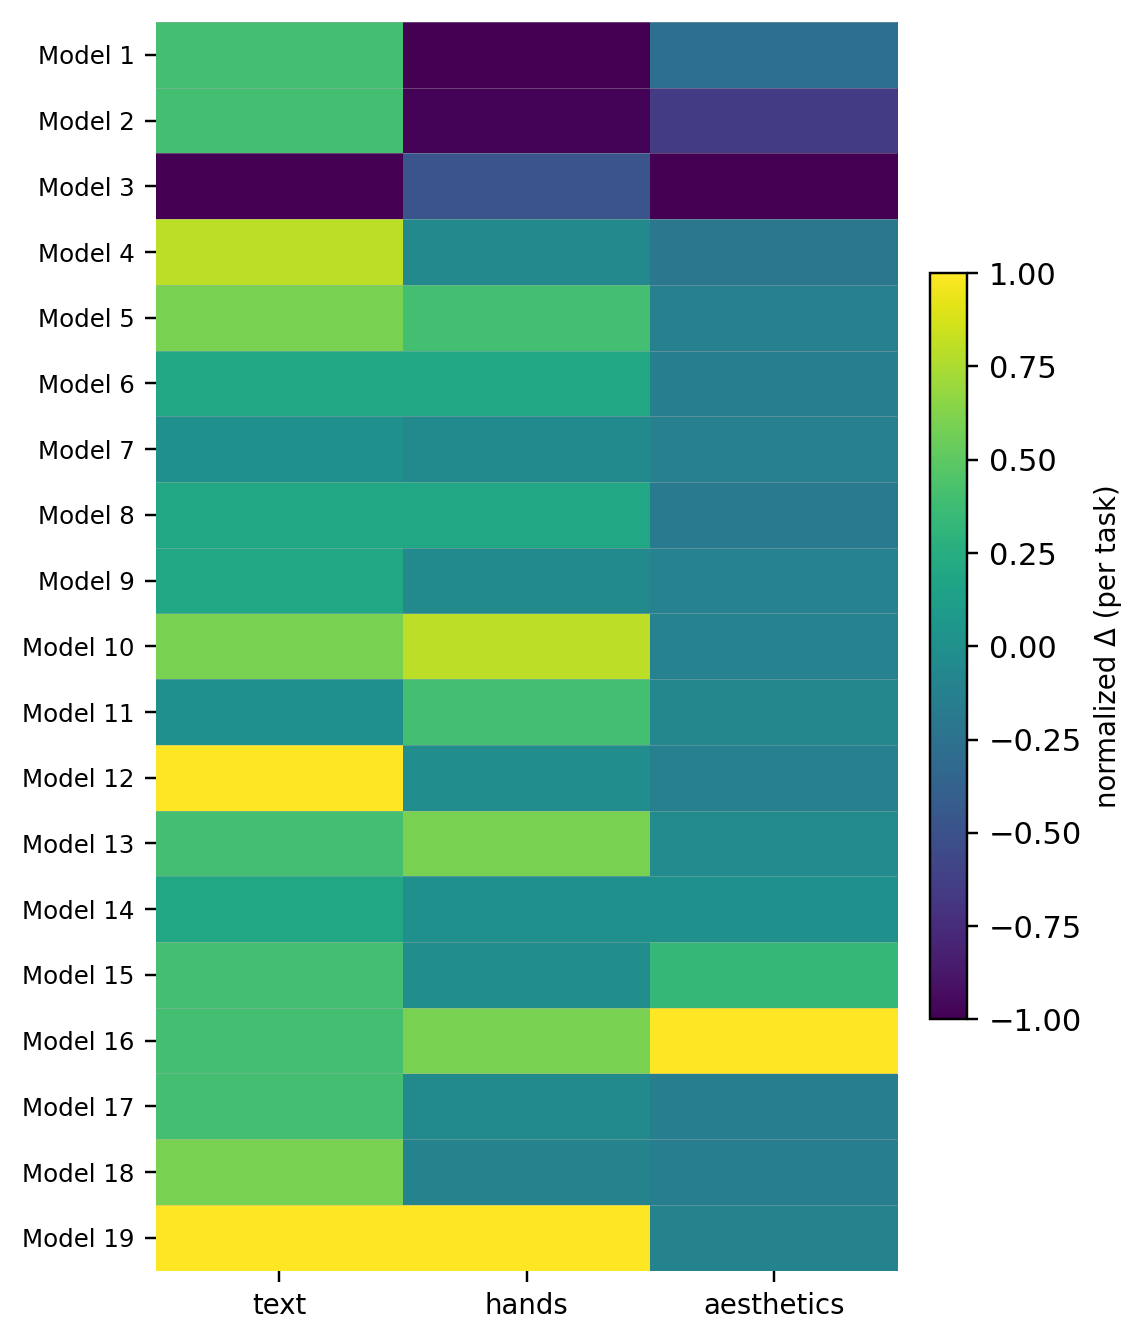

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# === Replace these strings with your data ===
task_text = """
2%
2%
-10%
4%
3%
1%
0%
1%
1%
3%
0%
5%
2%
1%
2%
2%
2%
3%
5%
"""

task_hands = """
-49%
-48%
-23%
-3%
2%
1%
-2%
1%
-2%
4%
2%
-1%
3%
0%
-1%
3%
-2%
-5%
5%
"""

task_aesthetics = """
-21%
-50%
-77%
-16%
-10%
-11%
-10%
-14%
-9%
-9%
-6%
-10%
-3%
0%
1%
3%
-11%
-11%
-8%
"""

def parse_percent_column(s: str) -> np.ndarray:
    return np.array([float(tok[:-1]) for tok in s.replace(",", ".").split() if tok.endswith("%")], float)

def normalize_column(vec: np.ndarray) -> np.ndarray:
    out = np.zeros_like(vec, float)
    pos = vec > 0
    neg = vec < 0
    if pos.any():
        out[pos] = vec[pos] / vec[pos].max()      # max positive → +1
    if neg.any():
        out[neg] = vec[neg] / abs(vec[neg].min()) # min negative → -1
    return out

# Parse
col_text = parse_percent_column(task_text)
col_hands = parse_percent_column(task_hands)
col_aesthetics = parse_percent_column(task_aesthetics)

# Equalize lengths
n = min(len(col_text), len(col_hands), len(col_aesthetics))
col_text, col_hands, col_aesthetics = col_text[:n], col_hands[:n], col_aesthetics[:n]

# Normalize *per task*
norm_text = normalize_column(col_text)
norm_hands = normalize_column(col_hands)
norm_aesth = normalize_column(col_aesthetics)

# Stack → rows = models, columns = tasks
data = np.vstack([norm_text, norm_hands, norm_aesth]).T

fig, ax = plt.subplots(figsize=(5.3, 6.2), dpi=220)

# Standard heatmap colors — change "viridis" to "coolwarm" if you want diverging
im = ax.imshow(data, aspect='auto', cmap="viridis", vmin=-1, vmax=1)

# Labels
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["text", "hands", "aesthetics"], fontsize=9)

ax.set_yticks(range(data.shape[0]))
ax.set_yticklabels([f"Model {i+1}" for i in range(data.shape[0])], fontsize=8)

# No overall title

# Light gridlines between rows (optional, keeps clean look)
for s in ax.spines.values(): s.set_visible(False)
ax.set_yticks(np.arange(-.5, data.shape[0], 1), minor=True)
ax.grid(which='minor', axis='y', linestyle='-', linewidth=0.3, alpha=0.4)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("normalized Δ (per task)", fontsize=9)

plt.tight_layout()
plt.show()